## 1. Imports

In [2]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 錯誤(ERROR)
import pandas as pd
import numpy as np
import seaborn as sns
from PIL import Image, ImageOps
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras import optimizers

#from keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow as tf
import matplotlib.pyplot as plt 

2026-02-25 10:12:19.014946: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-25 10:12:19.086848: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-25 10:12:19.109151: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import os, psutil
p = psutil.Process(os.getpid())
print("PID:", os.getpid())
print("RSS(MB):", p.memory_info().rss/1024/1024)

PID: 34502
RSS(MB): 813.7265625


In [4]:
import gc
gc.collect()

0

## 2. Loading Data

In [9]:
# images = []

# 原本是將圖片讀進來，但會爆記憶體，現改用路徑方式讀取
paths = []
ages = []

for i in os.listdir('../dataset/dataset/UTKFace/'): #選全部
    split = i.split('_')
    ages.append(int(split[0]))
    # images.append(Image.open('../dataset/UTKFace/' + i))
    paths.append(f'../dataset/dataset/UTKFace/{i}')

In [10]:
#將path和age放入DataFrame
df = pd.DataFrame({'path': paths, 'age': ages})
df

,path,age
0,../dataset/dataset/UTKFace/100_0_0_20170112213...,100
1,../dataset/dataset/UTKFace/100_0_0_20170112215...,100
2,../dataset/dataset/UTKFace/100_1_0_20170110183...,100
3,../dataset/dataset/UTKFace/100_1_0_20170112213...,100
4,../dataset/dataset/UTKFace/100_1_0_20170112213...,100
...,...,...
23703,../dataset/dataset/UTKFace/9_1_3_2016122022285...,9
23704,../dataset/dataset/UTKFace/9_1_3_2017010422294...,9
23705,../dataset/dataset/UTKFace/9_1_4_2017010320063...,9
23706,../dataset/dataset/UTKFace/9_1_4_2017010320081...,9


'../dataset/dataset/UTKFace/100_0_0_20170112213500903.jpg.chip.jpg'

Age: 100


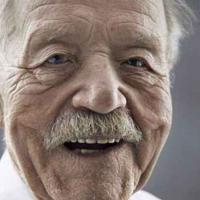

Age: 100


In [11]:
#打印df的第一筆資料，檢查是否正確
display(df['path'][0])
print("Age:",df['age'][0])

#開啟位置0的圖片
p = df.loc[0, 'path']
img = Image.open(p)
display(img)
print("Age:", df.loc[0, 'age'])

'../dataset/dataset/UTKFace/16_1_0_20170117133441179.jpg.chip.jpg'

Age: 16


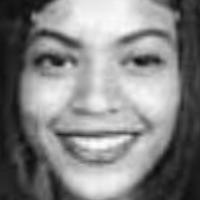

Age: 16


In [12]:
display(df['path'][1000])
print("Age:",df['age'][1000])

p = df.loc[1000, 'path']
img = Image.open(p)

display(img)
print("Age:", df.loc[1000, 'age'])

## 3. Visualising and Preparing Data

### 3-1：可視化檢查資料分布。

/tmp/ipykernel_34502/3932489017.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'],kde=True, bins=50) #bins=x ，表將資料分散於x個區間內


<Axes: xlabel='age', ylabel='Density'>

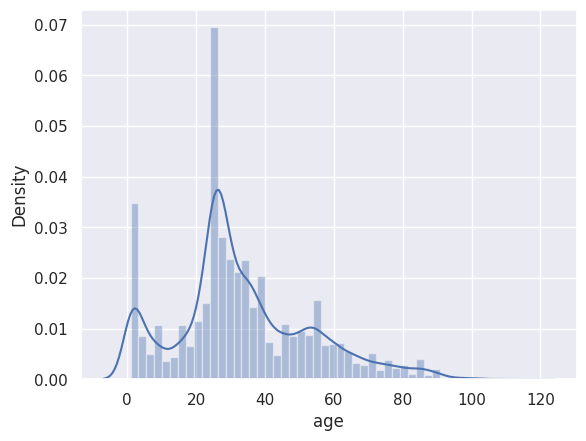

In [13]:
sns.set_theme()
sns.distplot(df['age'],kde=True, bins=50) #bins=x ，表將資料分散於x個區間內

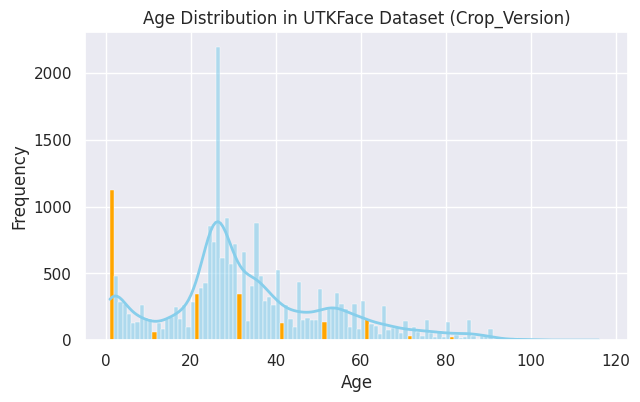

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already created and contains the 'Ages' column
plt.figure(figsize=(7, 4))

# Create a histogram with one bin per year
# ax = sns.histplot(df['Ages'], bins=range(df['Ages'].min(), df['Ages'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)
ax = sns.histplot(df['age'], bins=range(df['age'].min(), df['age'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)

# Get the patches used in the histogram
patches = ax.patches

# Color every 10th bin starting from 1 (1, 11, 21, ...) in orange
for patch in patches:
    bin_center = patch.get_x() + patch.get_width() / 2
    if (int(bin_center) - 1) % 10 == 0:
        patch.set_facecolor('orange')

plt.title('Age Distribution in UTKFace Dataset (Crop_Version)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### 3-2：找出極端數值，先切掉。

In [15]:
import numpy as np

ages_np = np.array(ages, dtype=int)

unique, counts = np.unique(ages_np, return_counts=True)
top_idx = counts.argmax()
down_idx = counts.argmin()
# all_indexs = np.arange(len(unique))

print("年齡種類數 =", len(unique))

top_age = unique[top_idx]
top_count = counts[top_idx]
print("最多的年齡 =", top_age, "出現次數 =", top_count)

down_age = unique[down_idx]
down_count = counts[down_idx]
print("最少的年齡 =", down_age, "出現次數 =", down_count)

年齡種類數 = 104
最多的年齡 = 26 出現次數 = 2197
最少的年齡 = 103 出現次數 = 1


In [16]:
threshold = 1000

mask = counts > threshold
result = list(zip(unique[mask], counts[mask]))

print(f"出現次數大於 {threshold} 的年齡：\n")
for age, count in result:
    print(f"{age} 歲出現 {count} 次")

出現次數大於 1000 的年齡：

1 歲出現 1123 次
26 歲出現 2197 次


把超過1000筆資料的年齡，全部砍到剩下1000張，以避免極端值影響模型泛化。

In [17]:
threshold = 1000

df = (
    df.sample(frac=1, random_state=42)   # 先把整份資料打亂（等價於每組隨機）
      .groupby("age", group_keys=False)
      .head(threshold)                    # 每個年齡只保留前 1000 筆
      .reset_index(drop=True)
)

In [18]:
vc = df["age"].value_counts()

print("所有年齡的數量：", len(vc))
print("是否還存在 >1000 的年齡？", (vc > 1000).any())
print("最大值：", vc.max())
print("前 10 個最常見年齡：")
print(vc.head(10))

所有年齡的數量： 104
是否還存在 >1000 的年齡？ False
最大值： 1000
前 10 個最常見年齡：
age
26    1000
1     1000
28     918
35     880
24     859
25     734
30     724
32     664
27     615
29     570
Name: count, dtype: int64


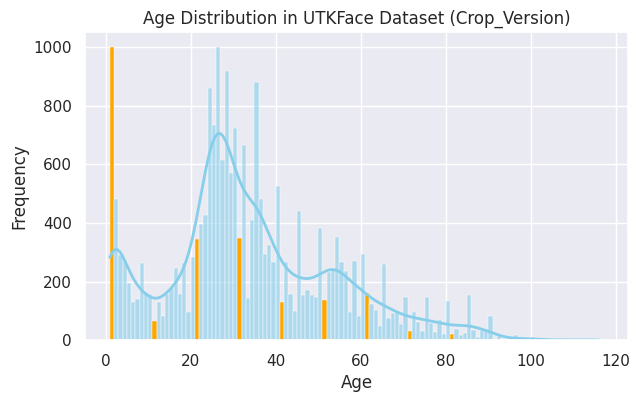

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already created and contains the 'Ages' column
plt.figure(figsize=(7, 4))

# Create a histogram with one bin per year
# ax = sns.histplot(df['Ages'], bins=range(df['Ages'].min(), df['Ages'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)
ax = sns.histplot(df['age'], bins=range(df['age'].min(), df['age'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)

# Get the patches used in the histogram
patches = ax.patches

# Color every 10th bin starting from 1 (1, 11, 21, ...) in orange
for patch in patches:
    bin_center = patch.get_x() + patch.get_width() / 2
    if (int(bin_center) - 1) % 10 == 0:
        patch.set_facecolor('orange')

plt.title('Age Distribution in UTKFace Dataset (Crop_Version)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

Too many faces of people between 0 and 4 years old. The model would fit too well to these ages and not enough to the other ages. To resolve this I'm only going to include a third of the images between these ages.

In [20]:
under4s = []

for i in range(len(df)):
    if df['age'].iloc[i] <= 4:
        under4s.append(df.iloc[i])
under4s = pd.DataFrame(under4s)
under4s = under4s.sample(frac=0.3)

df = df[df['age'] > 4]

df = pd.concat([df, under4s], ignore_index = True)

/tmp/ipykernel_34502/3898389991.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['age'],kde=True, bins=80)


<Axes: xlabel='age', ylabel='Density'>

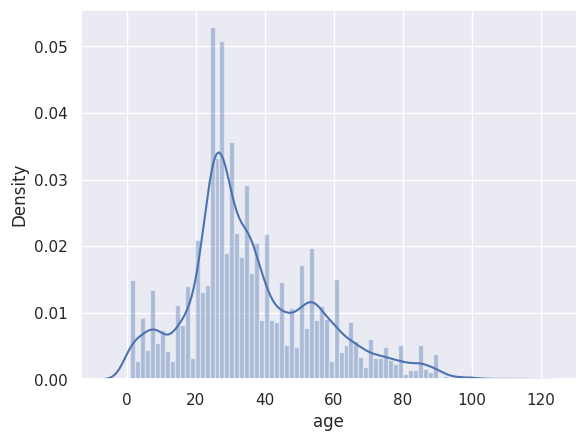

In [21]:
sns.distplot(df['age'],kde=True, bins=80)

This looks much better! The dataframe is more representative of the population now. However, there aren't many images of people over 80, which would cause the model to not train well enough on those ages. It's best to just remove over 80s and only have a model that can predict the ages of people under 80.

In [22]:
df = df[df['age'] < 80]

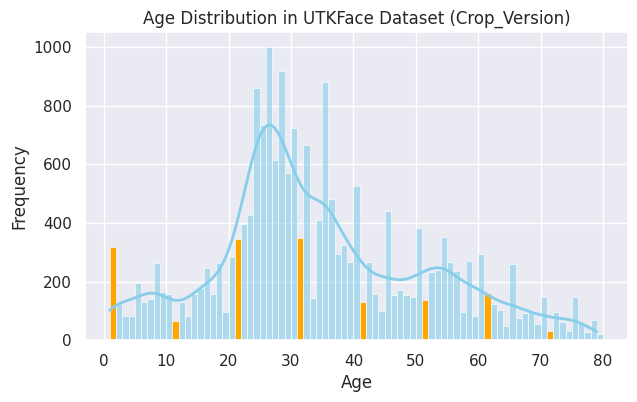

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming df is already created and contains the 'Ages' column
plt.figure(figsize=(7, 4))

# Create a histogram with one bin per year
# ax = sns.histplot(df['Ages'], bins=range(df['Ages'].min(), df['Ages'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)
ax = sns.histplot(df['age'], bins=range(df['age'].min(), df['age'].max() + 2), kde=True, color="skyblue", line_kws={'linewidth': 2}, alpha=0.6)

# Get the patches used in the histogram
patches = ax.patches

# Color every 10th bin starting from 1 (1, 11, 21, ...) in orange
for patch in patches:
    bin_center = patch.get_x() + patch.get_width() / 2
    if (int(bin_center) - 1) % 10 == 0:
        patch.set_facecolor('orange')

plt.title('Age Distribution in UTKFace Dataset (Crop_Version)')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

## 4. Data augmentation setting 

### 4-1 : 先建立bins分箱。
用分箱的方式，避免單一年齡資料筆數極少。造成在特定單一年齡中過度重複使用相同圖片增強。<br>
By using partitioning 'bin', we avoid having extremely few data points for single age groups. This prevents excessive reuse of the same image enhancements within specific single age groups.

In [24]:
BIN = 5
AGE_MIN = int(df["age"].min())   # 依你的資料通常會是 1
AGE_MAX = int(df["age"].max())   # 依你的裁切通常會是 79

# edges: 例如 1,6,11,...,81（右邊界不含）
edges = np.arange(AGE_MIN, AGE_MAX + BIN + 1, BIN)
df["age_bin"] = pd.cut( df["age"], bins=edges, right=False, include_lowest=True)

# 檢查每個 bin 的數量（確認你分箱成功）
bin_counts = df["age_bin"].value_counts().sort_index()
display(bin_counts)
print("bin 數 =", len(bin_counts))

age_bin
[1, 6)       809
[6, 11)      855
[11, 16)     610
[16, 21)    1049
[21, 26)    2760
[26, 31)    3827
[31, 36)    2446
[36, 41)    1893
[41, 46)    1095
[46, 51)    1005
[51, 56)    1232
[56, 61)     979
[61, 66)     698
[66, 71)     474
[71, 76)     374
[76, 81)     178
Name: count, dtype: int64

bin 數 = 16


### 4-2 : 將分箱好的資料分train, test, val set。
建立好 年齡分箱 bins。
接著，再將分箱好的資料分train, test, val。<br>

Set up age bins.
Next, split the bin-sorted data into train, test, and validation sets.

In [25]:
# 先切出 train / tmp
df_train, df_tmp = train_test_split(df, test_size=0.2, random_state=42, stratify=df["age_bin"] )

# tmp 再切 val / test（各 10%）
df_val, df_test = train_test_split( df_tmp, test_size=0.5, random_state=42, stratify=df_tmp["age_bin"] )

print("訓練集大小 =", len(df_train), "測試集大小 =", len(df_test), "驗證集大小 =", len(df_val))


訓練集大小 = 16227 測試集大小 = 2029 驗證集大小 = 2028


In [26]:
print("train bins =", df_train["age_bin"].nunique(),
      "val bins =", df_val["age_bin"].nunique(),
      "test bins =", df_test["age_bin"].nunique())

train bins = 16 val bins = 16 test bins = 16


In [27]:
min_cnt = df["age_bin"].value_counts().min()
print("min bin count:", min_cnt)

min bin count: 178


### 4-3 : Data Load and Process Pipeline Build

因為一開始使用path, age label，來做df，以避免預先載入的圖片耗掉大量空間。會在進行訓練時，才將圖片載入。<br>
所以這裡要做一個 LoadandProcess Function 來讀取df，轉換成圖片以及準備進入模型訓練的格式。<br>

Initially, we use path and age labels to create the dataframe, avoiding preloading images that would consume excessive storage. Images will be loaded only during training.<br>

Therefore, we need a LoadandProcess function to read the dataframe, convert it into images, and prepare it for model training.

In [ ]:
#這裡用來清除為了加快input pipeline所寫入的cache。
#當你重新訓練一次時，就跑一次這個。
# import os, glob

# patterns = [
#     "/tmp/utk_val.cache*",
#     "/tmp/utk_test.cache*",
#     "/tmp/utk_bin_*.cache*",
# ]

# for p in patterns:
#     for f in glob.glob(p):
#         try:
#             os.remove(f)
#         except OSError:
#             pass


In [29]:
IMG_SIZE = (200, 200)

# 讀取df的圖片並做前處理，前處理是為了讓圖片變成模型可以接受的格式
# 耗時操作就是 tf.io.read_file / decode_jpeg / resize
def load_and_preprocess(path, age):
    img_bytes = tf.io.read_file(path) 
    img = tf.image.decode_jpeg(img_bytes, channels=3)   # UTKFace 通常是 jpeg 
    img = tf.image.resize(img, IMG_SIZE) 
    img = tf.cast(img, tf.float32)  #這行是img轉成float32 並正規化，為了要讓數值介於0~1之間(後來放到模型裡做正規化了，所以這裡就不做了)
    age = tf.cast(age, tf.float32) #這行是將age轉成float32
    return img, age

def make_ds_from_df(df_part, training=False, cache_path=None):
    paths = df_part["path"].astype(str).to_numpy()
    ages  = df_part["age"].astype(np.float32).to_numpy()

    ds = tf.data.Dataset.from_tensor_slices((paths, ages))

    #  map：讀檔/解碼/resize
    #使用num_parallel_calls=tf.data.AUTOTUNE來自動調整並行處理的線程數量
    #並將deterministic設為False，放寬順序要求以提升效能
    #這樣做的前提是訓練本來就會shuffle， 我們不在乎資料的順序
    ds = ds.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE, deterministic=False) 

    #cache：把「已經 decode+resize 的結果」存起來
    if cache_path is not None:
        ds = ds.cache(cache_path) # cache 到本機檔案（建議用 SSD 路徑）

    # if training:
    #     ds = ds.map(lambda x, y: (augment(x, training=True), y),
    #                 num_parallel_calls=tf.data.AUTOTUNE, deterministic=False)
    return ds


### 4-4 : 設定分箱區間的曝光數量與取樣
Setting the expose and sampling

In [30]:
# EXPOSE = 3000
EXPOSE = 10432
BATCH = 64

num_bins = df_train["age_bin"].nunique()
k = max(1, EXPOSE // num_bins)

bin_datasets = []
for i, (bin_key, g) in enumerate(df_train.groupby("age_bin", observed=True)):
    ds_bin = make_ds_from_df(g, training=True, cache_path=f"/tmp/utk_bin_{i}.cache")
    ds_bin = ds_bin.shuffle(buffer_size=min(len(g), 2000), reshuffle_each_iteration=True)
    # ds_bin = ds_bin.repeat().take(k)   # 每個 epoch 從這個 bin 抽 k 筆（不足就 repeat）
    ds_bin = ds_bin.repeat() # 允許 oversampling（取樣可重複）
    bin_datasets.append(ds_bin)

#用sample_from_datasets，把每個bin當成一個子資料集，訓練時，從這些子資料集中隨機取樣組合成新的資料集
ds_train = tf.data.Dataset.sample_from_datasets(bin_datasets) \
            .take(EXPOSE) \
            .batch(BATCH) \
            .prefetch(tf.data.AUTOTUNE)

# ds_train = bin_datasets[0]
# for ds_next in bin_datasets[1:]:
#     ds_train = ds_train.concatenate(ds_next)

# ds_train = ds_train.shuffle(buffer_size=EXPOSE).batch(BATCH).prefetch(tf.data.AUTOTUNE)


I0000 00:00:1772014442.091992   34502 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772014442.448612   34502 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772014442.448716   34502 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772014442.451994   34502 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1772014442.452056   34502 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:65:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

### 以下檢查為什麼 資料處理的速度很慢
Below is checking what's the reason that data preprocess is very slow. 

In [31]:
# print("model input shape:", agemodel.input_shape)

In [32]:
# import tensorflow as tf
# import time

# # 這裡把 H, W 改成你剛剛印出來的數字
# H, W = 200, 200   # <- 你要改這行
# C = 3

# def make_synth_ds(batch_size):
#     # x: 假圖片（跟你訓練時的圖片張量形狀一致）
#     x = tf.random.uniform((batch_size, H, W, C), 0.0, 1.0, dtype=tf.float32)
#     # y: 假年齡標籤（形狀用 (batch, ) 最保險；必要時你再改成 (batch,1)）
#     y = tf.random.uniform((batch_size,), 0.0, 80.0, dtype=tf.float32)

#     ds = tf.data.Dataset.from_tensors((x, y)).repeat()
#     ds = ds.prefetch(tf.data.AUTOTUNE)
#     return ds


In [33]:
# class StepCounter(tf.keras.callbacks.Callback):
#     def on_train_begin(self, logs=None):
#         self.steps = 0
#     def on_train_batch_end(self, batch, logs=None):
#         self.steps += 1

# def benchmark_fit(ds, steps=200, warmup=20, label=""):
#     # 1) warmup：用一個 repeat，讓 tracing / 初始開銷先跑掉
#     agemodel.fit(ds.repeat(), steps_per_epoch=warmup, epochs=1, verbose=0)

#     # 2) 正式量測：再用一個 repeat，讓量測段從乾淨 iterator 開始
#     cb = StepCounter()
#     cb.steps = 0

#     t0 = time.perf_counter()
#     agemodel.fit(ds.repeat(), steps_per_epoch=steps, epochs=1, verbose=0, callbacks=[cb])
#     t1 = time.perf_counter()

#     # 3) 用「實際跑到的 batch 數」當分母（理論上會等於 steps）
#     sec_per_step = (t1 - t0) / cb.steps
#     print(f"{label} steps_ran={cb.steps} / target_steps={steps}")
#     print(f"{label} total={t1-t0:.2f}s, sec/step={sec_per_step:.4f}")
#     return sec_per_step


# # 你 notebook 已有 BATCH 變數就用它；沒有就自己設一個跟訓練相同的
# BATCH = 64
# synth_ds = make_synth_ds(BATCH)

# real_speed  = benchmark_fit(ds_train,  steps=200, warmup=20, label="REAL")
# synth_speed = benchmark_fit(synth_ds,  steps=200, warmup=20, label="SYNTH")

# print("SYNTH / REAL ratio =", synth_speed / real_speed)


REAL steps_ran=200 / target_steps=200 <br>
REAL total=116.08s, sec/step=0.5804 <br>
SYNTH steps_ran=200 / target_steps=200 <br>
SYNTH total=10.01s, sec/step=0.0501 <br>
SYNTH / REAL ratio = 0.08627915845111392 <br>
這樣的結果表示我們的input pieline需要優化。

檢查結束

## 5. Training Model

In [34]:
# 這裡就是在做噪音
# 只對 train 做 augmentation（避免資料洩漏）
augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomZoom(0.05),
])

agemodel = Sequential([
    Input(shape=(200, 200, 3)),
    augment,
    tf.keras.layers.Rescaling(1./255),
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),
    Flatten(),
    Dense(64, activation="relu"),
    Dropout(0.5),
    Dense(1)
])

agemodel.compile(loss='mean_squared_error',
             optimizer=optimizers.Adam(learning_rate=0.0001),
             metrics=["mae"])

In [35]:
agemodel.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential (Sequential)     (None, 200, 200, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 200, 200, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 198, 198, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 99, 99, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 97, 97, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 48, 48, 64)        0         
 g2D)                                                 

In [36]:
# validation：不做 augmentation、也不做 repeat / shuffle / bin-expose
ds_val = make_ds_from_df(df_val, training=False, cache_path="/tmp/utk_val.cache") \
            .batch(BATCH) \
            .prefetch(tf.data.AUTOTUNE)

ds_test = make_ds_from_df(df_test, training=False, cache_path="/tmp/utk_test.cache") \
            .batch(BATCH) \
            .prefetch(tf.data.AUTOTUNE)

In [ ]:
history = agemodel.fit(ds_train, epochs=60, validation_data=ds_val)

## 6. Visualize Training Result

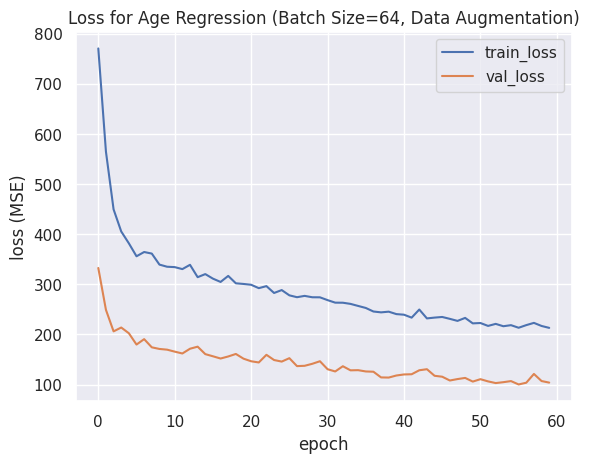

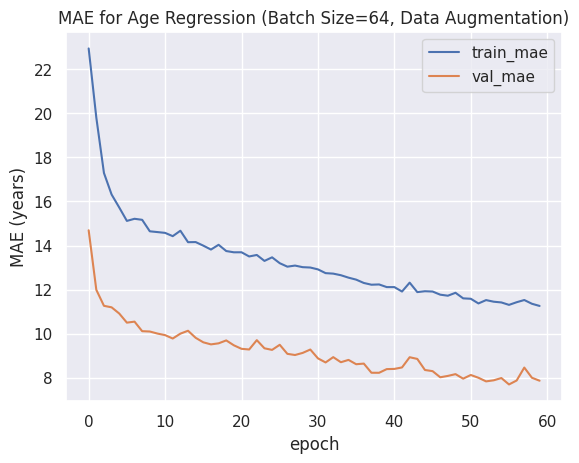

In [38]:
import matplotlib.pyplot as plt
save_dir = "/workspace/output"
os.makedirs(save_dir, exist_ok=True)

plt.figure()
plt.title('Loss for Age Regression (Batch Size=64, Data Augmentation)')
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("epoch")
plt.ylabel("loss (MSE)")
plt.legend()
plt.savefig(os.path.join(save_dir, "age_DataAugmentation_loss_batch64.png"))
plt.show()

plt.figure()
plt.title('MAE for Age Regression (Batch Size=64, Data Augmentation)')
plt.plot(history.history["mae"], label="train_mae")
plt.plot(history.history["val_mae"], label="val_mae")
plt.xlabel("epoch")
plt.ylabel("MAE (years)")
plt.legend()
plt.savefig(os.path.join(save_dir, "age_DataAugmentation_mae_batch64.png"))
plt.show()

In [56]:
import numpy as np
import pandas as pd

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2' # 錯誤(ERROR)

h = history.history  

df_hist = pd.DataFrame(h)
df_hist.index = df_hist.index + 1  # epoch從1開始比較直觀

# 找 val_loss 最低的 epoch（你也可以改成 val_mae 最低）
best_epoch = int(df_hist["val_loss"].idxmin())
best_row = df_hist.loc[best_epoch]

print("===== 最佳驗證表現（以 val_loss 最低） =====")
print(f"Best epoch: {best_epoch}")
print(best_row.to_string())

print("\n===== 最終 epoch 數值 =====")
print(df_hist.iloc[-1].to_string())

===== 最佳驗證表現（以 val_loss 最低） =====
Best epoch: 56
loss        213.269073
mae          11.308442
val_loss    100.203194
val_mae       7.697378

===== 最終 epoch 數值 =====
loss        213.045670
mae          11.260182
val_loss    103.881409
val_mae       7.866970


In [ ]:
import os, glob
#先把為了加快input pipeline所寫入的cache清除掉，再去評估測試集，這樣才不會有cache的資料干擾到測試集的評估結果。
patterns = [
    "/tmp/utk_val.cache*",
    "/tmp/utk_test.cache*",
    "/tmp/utk_bin_*.cache*",
]

for p in patterns:
    for f in glob.glob(p):
        try:
            os.remove(f)
        except OSError:
            pass

test_loss, test_mae = agemodel.evaluate(ds_test, verbose=0)
print("===== Test set =====")
print("test_loss(MSE):", float(test_loss))
print("test_mae:", float(test_mae))

===== Test set =====
test_loss(MSE): 101.85385131835938
test_mae: 7.832045555114746


## 7. Model Save

In [40]:
save_dir = "/workspace/csv_result"
os.makedirs(save_dir, exist_ok=True)

out_csv = "training_history_ML_AgePredict_DataAugmentation_0225.csv"
df_hist.to_csv(os.path.join(save_dir, out_csv), index_label="epoch")
print("saved:", out_csv)

saved: training_history_ML_AgePredict_DataAugmentation_0225.csv


In [41]:
save_dir = "/workspace/models"
os.makedirs(save_dir, exist_ok=True)

agemodel.save(os.path.join(save_dir, "Age_Model_DataAugmentation.keras"))  # 建議用 .keras